# POSE — `infer.ipynb` : ein Bild -> 6D-Pose

Nimmt **ein Bild aus `project/input/`** und lässt es durch die volle Inferenz-
Pipeline laufen, **jede Stufe sichtbar**:

| Stufe | Was | Output |
|---|---|---|
| 0 · Setup | Pfade, Modelle + Registry aus `project/models/` laden | — |
| 1 · Teile finden | **OBB-Detektor** (`models/detector.pt`, YOLOv8-OBB) -> orientierte Boxen + Klasse | Detections |
| 2 · Crop | pro Detection den BBox-Ausschnitt (opt. Maskenfreistellung) | Crops |
| 3 · Face klassifizieren | CNN (`models/<part>.pt`), sonst Nearest-Template-Fallback | Face + Konfidenz |
| 4 · 6D-Alignment | Yaw aus dem OBB-Winkel (Flip per Template-MSE), `Rz(yaw)·R_face`, Backprojection | R_world, t_world |
| 5 · pose_result | Schema-valides `pose_result.json` (Contract) + 3D-Inline + Live-Viewer | JSON + 3D |

**Konvention:** Z-up Welt, `world = R @ body` (Spaltenkonvention), Ursprung =
Tisch-Nullpunkt — eingefroren im Contract, nie transponiert.

Alle Pipeline-Funktionen sind **inline** dokumentiert (keine Imports auf
Projektmodule). Bewusst dupliziert mit `e2e_infer.py` / `setup.ipynb` — damit
das Notebook für sich allein lesbar und weitergebbar ist.

> **Detektor:** `models/detector.pt` ist ein echt trainierter YOLOv8-OBB-Detektor
> (YOLOv8s-OBB auf 420 SDG-Multi-Part-Szenen, 5 Klassen, mAP50 ≈ 0.99). Er findet die Teile als orientierte
> Boxen. Fehlt die `.pt` oder `ultralytics`, fällt Stufe 1 sauber auf die
> SDG-Annotator-Boxen (`bbox_2d_<idx>.json`) bzw. eine Dummy-Box zurück.


## 0 · Setup — Pfade, Modelle + Registry laden

In [1]:
import os, sys, json, pathlib, glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy import ndimage

PROJECT = pathlib.Path.cwd()
if PROJECT.name != "project":
    cand = PROJECT / "project"
    PROJECT = cand if cand.is_dir() else PROJECT
INPUT     = PROJECT / "input"
MODELS    = PROJECT / "models"
REGISTRY  = MODELS / "registry"
TEMPLATES = MODELS / "templates"          # Template-Banken (bank.npz pro Teil)
TEMP      = PROJECT / "temp"
TEMP.mkdir(parents=True, exist_ok=True)

print("Modelle:", sorted(p.name for p in MODELS.glob("*.pt")) or "(keine .pt — Fallback wird genutzt)")
print("Registries:", sorted(d.name for d in REGISTRY.iterdir() if d.is_dir()) if REGISTRY.is_dir() else "(keine)")
_banks = sorted(d.name for d in TEMPLATES.iterdir() if (d / "bank.npz").exists()) if TEMPLATES.is_dir() else []
print("Template-Banken:", _banks or "(keine — Pose fällt auf Yaw-Suche zurück)")
print("Input-Bilder:", sorted(p.name for p in INPUT.glob("*")) or "(leer — Stufe 1 legt ein Beispiel an)")

Modelle: ['Buerstenhalter_2polig.pt', 'Zahnrad.pt', 'detector.pt']
Registries: ['Anker_Kurz', 'Anker_Lang', 'Buerstenhalter_2polig', 'Getriebegehaeuse_typ4', 'Poltopf_kurz_centered', 'Zahnrad']
Template-Banken: ['Anker_Kurz', 'Anker_Lang', 'Buerstenhalter_2polig', 'Getriebegehaeuse_typ4', 'Poltopf_kurz_centered', 'Zahnrad']
Input-Bilder: ['.gitkeep', 'bbox_2d_scene.json', 'scene_0000.png', 'semantic_labels_scene.json']


### Inline: Registry-Loader

Die Registry (`models/registry/<part>/`) ist die Quelle der Wahrheit für Face-
Namen, Ruhe-Rotationen `R_face` und Yaw-Templates. `R_face` ist die kanonische
`world = R @ body`-Spaltenrotation aus `faces_<part>.json` — wird komponiert,
nie transponiert.


In [2]:
class Face:
    def __init__(self, name, prob, tilt_deg, R_face, template_path, index):
        self.name=name; self.prob=prob; self.tilt_deg=tilt_deg
        self.R_face=R_face; self.template_path=template_path; self.index=index

class PartRegistry:
    def __init__(self, part, convention, faces):
        self.part=part; self.convention=convention; self.faces=faces
    def resolve_face(self, classifier_face):
        """classifier-Face-Id -> Registry-Face. Akzeptiert 'Face 1', 'face_1',
        bare Index; Fallback = wahrscheinlichste Face (Contract bleibt gültig)."""
        if not self.faces: return None
        for f in self.faces:
            if f.name == classifier_face: return f
        norm = classifier_face.strip().lower().replace("face","").replace("_","").replace(" ","")
        if norm.isdigit():
            for f in self.faces:
                if f.index == int(norm): return f
        return max(self.faces, key=lambda f: f.prob)

def load_part_registry(part, root=REGISTRY):
    """models/registry/<part>/faces_<part>.json -> PartRegistry (oder None)."""
    pdir = pathlib.Path(root) / part
    jp = pdir / f"faces_{part}.json"
    if not jp.exists(): return None
    data = json.load(open(jp)); faces = []
    for k, fc in enumerate(data.get("faces", []), start=1):
        R = np.asarray(fc.get("R", []), float)
        R = R.reshape(3, 3) if R.size == 9 else np.eye(3)
        tp = pdir / f"tmpl_Face{k}.png"
        faces.append(Face(str(fc.get("name", f"Face {k}")), float(fc.get("prob", 0.0)),
                          float(fc.get("tilt_deg", 0.0)), R, str(tp) if tp.exists() else None, k))
    return PartRegistry(data.get("part", part), data.get("convention", "world = R @ body (column)"), faces)

def load_template(face, size=96):
    if not face.template_path or not os.path.exists(face.template_path): return None
    img = np.asarray(Image.open(face.template_path).convert("L").resize((size, size)))
    return img.astype(np.float32) / 255.0

def available_parts(root=REGISTRY):
    root = pathlib.Path(root)
    return sorted(d.name for d in root.iterdir() if d.is_dir() and (d/f"faces_{d.name}.json").exists()) if root.is_dir() else []

print("Registry-Parts:", available_parts())


Registry-Parts: ['Anker_Kurz', 'Anker_Lang', 'Buerstenhalter_2polig', 'Getriebegehaeuse_typ4', 'Poltopf_kurz_centered', 'Zahnrad']


## 1 · Teile finden — OBB-Detektor (echt trainiert)

Der **YOLOv8-OBB-Detektor** (`models/detector.pt`) lokalisiert jedes Teil als
**orientierte Bounding-Box** + Klasse. Trainiert auf den SDG-Multi-Part-Szenen
(Stufe 5, 420 Multi-Part-Szenen, 5 Klassen) — YOLOv8s-OBB, mAP50≈0.99.

Drei Quellen, in dieser Priorität (jede ein sauberer Fallback der vorigen):

1. **OBB-Detektor** — `models/detector.pt` via `ultralytics`. Liefert orientierte
   4-Eck-Boxen, Klasse, Konfidenz und den **OBB-Winkel** (Lang-Achse), der die
   Yaw-Schätzung in Stufe 4 seedet.
2. **SDG-Annotator** — fehlt die `.pt`/`ultralytics`, nehmen wir
   `bbox_2d_<idx>.json` (Isaac `bounding_box_2d_tight`) neben dem Bild.
3. **Dummy** — sonst eine ganze-Bild-Box, damit die Kette nie hart bricht.

Das Beispielbild legen wir aus `input/` ab (bzw. bereitstellen, falls leer).


In [3]:
# Ein Beispielbild bereitstellen, falls input/ leer ist.
def ensure_example_image():
    imgs = sorted(p for p in INPUT.glob("*") if p.suffix.lower() in (".png", ".jpg", ".jpeg"))
    if imgs: return imgs[0]
    # input/ ist leer: eine SDG-Szene reinlegen (setup.ipynb generate_scenes ->
    # data/output/big auf der Box, dann ein rgb_*.png nach project/input/ holen).
    print("[input] kein Bild in project/input/ — bitte eine SDG-Szene (rgb_*.png) "
          "ablegen (siehe setup.ipynb Stufe 1: generate_scenes).")
    return None

IMG_PATH = ensure_example_image()
print("Eingabebild:", IMG_PATH)


Eingabebild: /Users/Admin/POSE/project/input/scene_0000.png


In [4]:
# ── Detection-Quelle: OBB-Detektor (bevorzugt), sonst SDG-BBox-JSON, sonst Dummy
def _canonical_parts():
    return {p.lower(): p for p in available_parts()} or {
        n.lower(): n for n in ["Anker_Lang","Anker_Kurz","Zahnrad","Poltopf_kurz_centered",
                               "Getriebegehaeuse_typ4","Buerstenhalter_2polig"]}
_CANON = _canonical_parts()
def canonical_part(raw): return _CANON.get(raw.strip().lower(), raw)

# --- echter OBB-Detektor (models/detector.pt, lazy) ---------------------------
DETECTOR_FILE = MODELS / "detector.pt"
_DETECTOR = {}
def _load_detector():
    """YOLOv8-OBB lazy laden. None wenn keine .pt / kein ultralytics."""
    if "m" in _DETECTOR: return _DETECTOR["m"]
    m = None
    if DETECTOR_FILE.exists():
        try:
            from ultralytics import YOLO; m = YOLO(str(DETECTOR_FILE))
        except Exception as e:
            print(f"[detect] ultralytics/Checkpoint nicht ladbar ({e!r}) — Fallback")
    _DETECTOR["m"] = m; return m

def _obb_to_aabb(corners, W, H):
    xs=[c[0] for c in corners]; ys=[c[1] for c in corners]
    x0=max(0,min(int(round(min(xs))),W-1)); x1=max(0,min(int(round(max(xs))),W))
    y0=max(0,min(int(round(min(ys))),H-1)); y1=max(0,min(int(round(max(ys))),H))
    return [x0,y0,x1,y1]

def _obb_angle_deg(corners):
    p=np.asarray(corners,float); e01=p[1]-p[0]; e12=p[2]-p[1]
    le = e01 if np.hypot(*e01)>=np.hypot(*e12) else e12
    return float(np.degrees(np.arctan2(le[1], le[0])))

def detect_with_model(img_path):
    """Orientierte Detektionen via detector.pt. [] wenn nicht verfügbar."""
    m = _load_detector()
    if m is None: return []
    rgb = np.asarray(Image.open(img_path).convert("RGB")); H, W = rgb.shape[:2]
    try:
        r = m.predict(str(img_path), imgsz=1280, conf=0.40, verbose=False)[0]
    except Exception as e:
        print(f"[detect] Inferenz fehlgeschlagen ({e!r}) — Fallback"); return []
    if r.obb is None or len(r.obb)==0: return []
    polys=r.obb.xyxyxyxy.cpu().numpy(); cls=r.obb.cls.cpu().numpy().astype(int)
    conf=r.obb.conf.cpu().numpy(); names=r.names; dets=[]
    for inst,(poly,c,cf) in enumerate(zip(polys,cls,conf)):
        corners=[[float(x),float(y)] for x,y in poly]; bbox=_obb_to_aabb(corners,W,H)
        if (bbox[2]-bbox[0])<4 or (bbox[3]-bbox[1])<4: continue
        raw=names[int(c)]
        dets.append({"instance_id":inst,"part":canonical_part(raw),"bbox_2d":bbox,
                     "raw_label":raw,"occlusion":0.0,"obb_corners":corners,
                     "obb_angle_deg":_obb_angle_deg(corners),"det_conf":float(cf)})
    print(f"[detect] {len(dets)} orientierte Boxen vom OBB-Detektor (detector.pt)")
    return dets

# --- SDG-Annotator-Fallback ---------------------------------------------------
def find_bbox_json(img_path):
    img_path = pathlib.Path(img_path); stem = img_path.stem.replace("rgb_","").replace("scene_","")
    for cand in [img_path.parent / f"bbox_2d_{stem}.json", *sorted(img_path.parent.glob("bbox_2d_*.json"))]:
        if cand.exists(): return cand
    return None

def detections_for(img_path):
    """Detections fürs Bild: OBB-Detektor -> SDG-BBox-JSON -> Dummy."""
    rgb = np.asarray(Image.open(img_path).convert("RGB")); H, W = rgb.shape[:2]
    dets = detect_with_model(img_path)
    if dets: return rgb, dets
    bj = find_bbox_json(img_path)
    if bj is not None:
        data = json.load(open(bj)); rows = data.get("data", []); id2 = (data.get("info", {}) or {}).get("idToLabels", {})
        for inst, row in enumerate(rows):
            if len(row) < 5: continue
            raw = (id2.get(str(int(row[0])), {}) or {}).get("class", "")
            x0, x1 = sorted((int(round(row[1])), int(round(row[3]))))
            y0, y1 = sorted((int(round(row[2])), int(round(row[4]))))
            x0, x1 = max(0,min(x0,W-1)), max(0,min(x1,W)); y0, y1 = max(0,min(y0,H-1)), max(0,min(y1,H))
            if (x1-x0) < 4 or (y1-y0) < 4: continue
            dets.append({"instance_id": inst, "part": canonical_part(raw), "bbox_2d": [x0,y0,x1,y1],
                         "raw_label": raw, "occlusion": float(row[5]) if len(row) > 5 else 0.0})
        print(f"[detect] Fallback: {len(dets)} BBoxes aus SDG-Annotator {bj.name}")
    if not dets:
        part = available_parts()[0] if available_parts() else "Anker_Lang"
        dets = [{"instance_id": 0, "part": part, "bbox_2d": [0,0,W,H], "raw_label": part, "occlusion": 0.0}]
        print(f"[detect] DUMMY: eine ganze-Bild-BBox als '{part}'")
    return rgb, dets

RGB, DETS = detections_for(IMG_PATH)
print(f"Bild {RGB.shape}, {len(DETS)} Detections "
      f"({'OBB-Detektor' if DETS and 'obb_corners' in DETS[0] else 'SDG/Dummy'})")


[detect] 9 orientierte Boxen vom OBB-Detektor (detector.pt)
Bild (720, 1280, 3), 9 Detections (OBB-Detektor)


### Visualisierung — BBox-Overlay

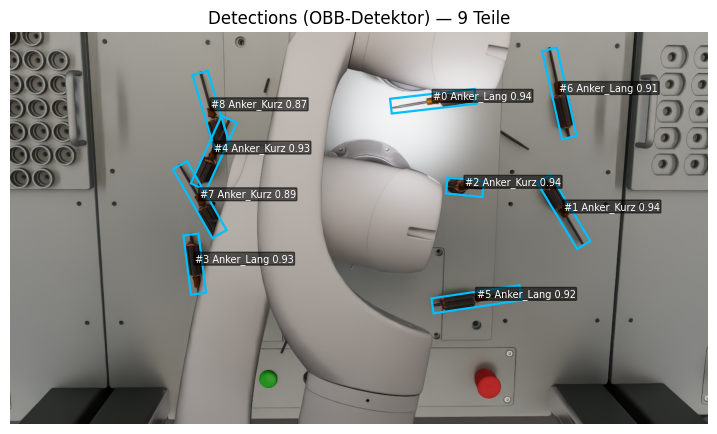

In [5]:
def show_detections(rgb, dets):
    """OBB-Polygone (vom Detektor) bzw. achsenparallele Boxen (Fallback) zeichnen."""
    from matplotlib.patches import Rectangle, Polygon
    fig, ax = plt.subplots(figsize=(9, 6)); ax.imshow(rgb)
    for d in dets:
        if "obb_corners" in d:                              # orientierte Box vom Detektor
            ax.add_patch(Polygon(d["obb_corners"], closed=True, fill=False,
                                 edgecolor="deepskyblue", lw=1.6))
            cx = sum(c[0] for c in d["obb_corners"]) / 4; cy = sum(c[1] for c in d["obb_corners"]) / 4
            lbl = f"#{d['instance_id']} {d['part']} {d.get('det_conf',0):.2f}"
        else:                                               # achsenparallele Fallback-Box
            x0, y0, x1, y1 = d["bbox_2d"]
            ax.add_patch(Rectangle((x0, y0), x1-x0, y1-y0, fill=False, edgecolor="lime", lw=1.5))
            cx, cy = x0, max(0, y0-3); lbl = f"#{d['instance_id']} {d['part']}"
        ax.text(cx, cy, lbl, color="white", fontsize=7, va="bottom",
                bbox=dict(boxstyle="round,pad=0.1", fc="black", alpha=0.55))
    src = "OBB-Detektor" if dets and "obb_corners" in dets[0] else "SDG/Dummy"
    ax.set_title(f"Detections ({src}) — {len(dets)} Teile"); ax.axis("off")
    plt.show()
show_detections(RGB, DETS)


## 2 · Crop — pro Detection den Ausschnitt

Der Crop ist das achsenparallele BBox-Rechteck. Liegt eine semantische
Segmentierung neben dem Bild, wird der Hintergrund auf Neutralgrau gesetzt, damit
der Classifier das Teil statt Nachbar-Clutter sieht. Ohne Seg: roher Crop
(funktioniert auch, der Classifier padded selbst auf Grau).


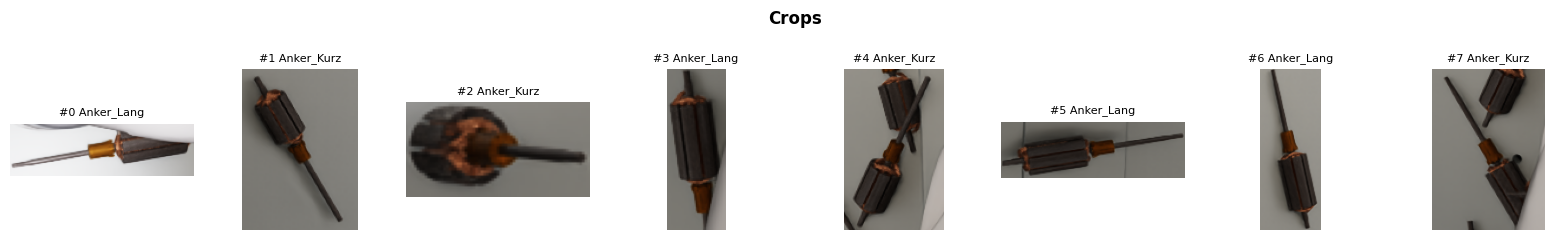

In [6]:
NEUTRAL = 128
def crop_detection(rgb, det):
    x0, y0, x1, y1 = det["bbox_2d"]
    return rgb[y0:y1, x0:x1].copy()

CROPS = [crop_detection(RGB, d) for d in DETS]

def show_crops(crops, dets, k=8):
    n = min(k, len(crops))
    if n == 0: print("keine Crops"); return
    fig, axs = plt.subplots(1, n, figsize=(2.0*n, 2.4), squeeze=False)
    for j in range(n):
        axs[0][j].imshow(crops[j]); axs[0][j].axis("off")
        axs[0][j].set_title(f"#{dets[j]['instance_id']} {dets[j]['part']}", fontsize=8)
    fig.suptitle("Crops", fontweight="bold"); fig.tight_layout(); plt.show()
show_crops(CROPS, DETS)


## 3 · Face-Vorfilter — CNN, sonst Nearest-Template-Fallback (optional)

`infer(crop, part)` -> `{"face", "confidence"}`. Seit der Template-Bank ist das
**nur noch ein optionaler Schnell-Vorfilter** (Log/Vis) — die eigentliche Pose
(Face + Yaw + R_world) kommt aus dem Bank-Match in Stufe 4. Zwei Backends,
automatisch, stürzt nie ab: trainiertes CNN (`models/<part>.pt`) wenn da, sonst
rotations-/spiegelinvariantes Nearest-Template gegen die Registry-Templates.

In [7]:
IMG_SIZE = 96
def _prep(crop, size=IMG_SIZE):
    """Quadrat-Pad auf Neutralgrau + Resize, RGB uint8."""
    a = np.asarray(crop)
    if a.ndim == 2: a = np.stack([a]*3, -1)
    if a.dtype != np.uint8: a = np.clip(a, 0, 255).astype(np.uint8)
    h, w = a.shape[:2]; sd = max(h, w); sq = np.full((sd, sd, 3), 128, np.uint8)
    sq[(sd-h)//2:(sd-h)//2+h, (sd-w)//2:(sd-w)//2+w] = a[:, :, :3]
    return np.asarray(Image.fromarray(sq).resize((size, size), Image.BILINEAR))

_MODEL_CACHE, _REF_CACHE = {}, {}

def _ckpt_path(part): return MODELS / f"{part}.pt"

def _load_model(part):
    """Trainiertes CNN laden (lazy torch). None wenn kein Checkpoint/torch."""
    if part in _MODEL_CACHE: return _MODEL_CACHE[part]
    ckpt = _ckpt_path(part)
    if not ckpt.exists(): _MODEL_CACHE[part] = None; return None
    try:
        import torch, torch.nn as nn
        def block(c,o): return nn.Sequential(nn.Conv2d(c,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(True),
                                             nn.Conv2d(o,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(True),nn.MaxPool2d(2))
        class Net(nn.Module):
            def __init__(s,n):
                super().__init__(); s.f=nn.Sequential(block(3,16),block(16,32),block(32,64),block(64,64))
                s.h=nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Flatten(),nn.Dropout(0.2),nn.Linear(64,n))
            def forward(s,x): return s.h(s.f(x))
        state = torch.load(ckpt, map_location="cpu")
        classes = state["classes"]; net = Net(len(classes)); net.load_state_dict(state["model"]); net.eval()
        _MODEL_CACHE[part] = (net, classes)
    except Exception:
        _MODEL_CACHE[part] = None
    return _MODEL_CACHE[part]

def _infer_model(crop, part):
    loaded = _load_model(part)
    if loaded is None: return None
    net, classes = loaded; import torch
    x = _prep(crop).astype(np.float32)/255.0
    x = torch.from_numpy(x.transpose(2,0,1))[None]
    with torch.no_grad(): probs = torch.softmax(net(x), 1)[0].numpy()
    k = int(np.argmax(probs)); return {"face": classes[k], "confidence": float(probs[k])}


In [8]:
def _grey(img):
    a = np.asarray(img).astype(np.float32)
    return a.mean(2)/255.0 if a.ndim == 3 else a/255.0

def _ncc_rot_mirror(a, b, step=10):
    """Bester NCC von a vs b über 360° Rotation + Spiegel (grau, normiert)."""
    best = -1.0
    for src in (a, a[:, ::-1]):
        for ang in range(0, 360, step):
            ar = ndimage.rotate(src, ang, reshape=False, order=1)
            m = (ar > 0.02) | (b > 0.02)
            if m.sum() < 20: continue
            x = ar[m]-ar[m].mean(); y = b[m]-b[m].mean()
            d = np.linalg.norm(x)*np.linalg.norm(y) + 1e-9; best = max(best, float((x @ y)/d))
    return best

def _load_refs(part):
    """Referenz-Greybilder pro Face fürs Fallback: die Registry-Templates."""
    if part in _REF_CACHE: return _REF_CACHE[part]
    reg = load_part_registry(part); refs = {}
    if reg:
        for f in reg.faces:
            if f.template_path:
                refs[f"face_{f.index}"] = _grey(_prep(np.asarray(Image.open(f.template_path).convert("RGB"))))
    _REF_CACHE[part] = refs; return refs

def _infer_fallback(crop, part):
    refs = _load_refs(part); reg = load_part_registry(part)
    classes = [f"face_{f.index}" for f in reg.faces] if reg else []
    if not refs:
        return {"face": classes[0] if classes else "face_1", "confidence": 0.0}
    q = _grey(_prep(crop)); scores = {c: _ncc_rot_mirror(q, r) for c, r in refs.items()}
    items = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
    best_cls, best = items[0]
    conf = (best - items[1][1]) / (abs(best)+1e-6) if len(items) > 1 else best
    return {"face": best_cls, "confidence": float(np.clip(conf, 0.0, 1.0))}

def infer(crop, part):
    """STABILE SIGNATUR. Checkpoint wenn da, sonst Nearest-Template-Fallback."""
    out = _infer_model(crop, part)
    return out if out is not None else _infer_fallback(crop, part)

def backend(part): return "checkpoint" if _load_model(part) is not None else "fallback"

# klassifizieren
CLASSIFIED = []
for d, crop in zip(DETS, CROPS):
    if d["part"] not in available_parts():
        print(f"[classify] unbekanntes Teil '{d['part']}' — skip"); continue
    res = infer(crop, d["part"])
    CLASSIFIED.append({**d, "crop": crop, "face": res["face"],
                       "confidence": res["confidence"], "backend": backend(d["part"])})
    print(f"[classify] #{d['instance_id']} {d['part']:<22} -> {res['face']:<8} "
          f"conf={res['confidence']:.2f} ({backend(d['part'])})")


[classify] #0 Anker_Lang             -> face_1   conf=0.00 (fallback)
[classify] #1 Anker_Kurz             -> face_1   conf=0.23 (fallback)
[classify] #2 Anker_Kurz             -> face_1   conf=0.26 (fallback)
[classify] #3 Anker_Lang             -> face_1   conf=0.13 (fallback)
[classify] #4 Anker_Kurz             -> face_1   conf=0.26 (fallback)
[classify] #5 Anker_Lang             -> face_1   conf=0.19 (fallback)


[classify] #6 Anker_Lang             -> face_1   conf=0.15 (fallback)
[classify] #7 Anker_Kurz             -> face_1   conf=0.24 (fallback)
[classify] #8 Anker_Kurz             -> face_1   conf=0.13 (fallback)


### Visualisierung — predicted Face neben Template

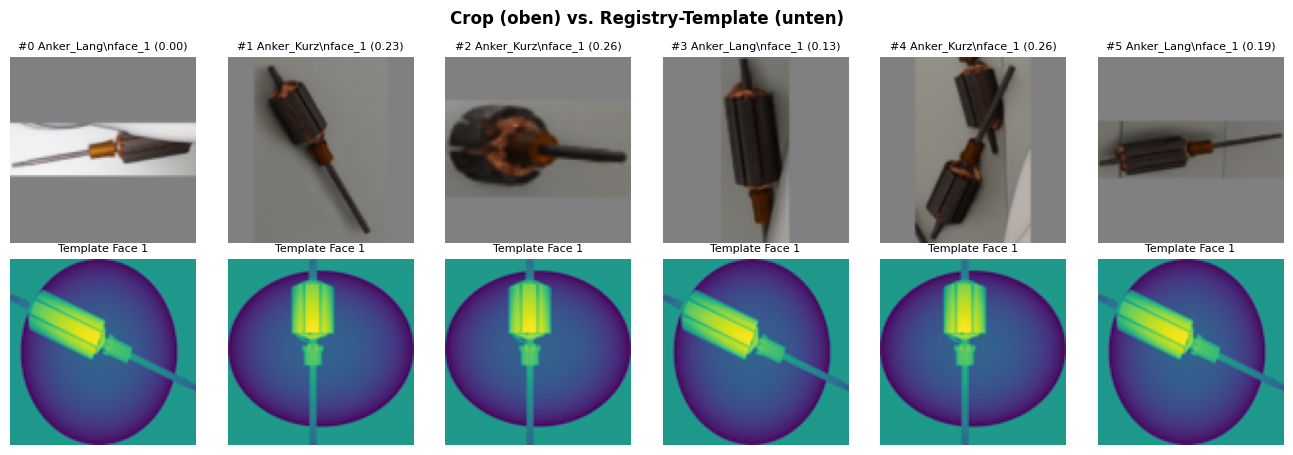

In [9]:
def show_classification(classified, k=6):
    items = classified[:k]
    if not items: print("nichts klassifiziert"); return
    fig, axs = plt.subplots(2, len(items), figsize=(2.2*len(items), 4.6), squeeze=False)
    for j, it in enumerate(items):
        axs[0][j].imshow(_prep(it["crop"])); axs[0][j].axis("off")
        axs[0][j].set_title(f"#{it['instance_id']} {it['part']}\\n{it['face']} ({it['confidence']:.2f})", fontsize=8)
        reg = load_part_registry(it["part"]); f = reg.resolve_face(it["face"]) if reg else None
        tmpl = load_template(f) if f else None
        axs[1][j].axis("off")
        if tmpl is not None:
            axs[1][j].imshow(tmpl, cmap="viridis"); axs[1][j].set_title(f"Template {f.name}", fontsize=8)
        else:
            axs[1][j].set_title("kein Template", fontsize=8)
    fig.suptitle("Crop (oben) vs. Registry-Template (unten)", fontweight="bold"); fig.tight_layout(); plt.show()
show_classification(CLASSIFIED)


## 4 · 6D-Pose — Template-Bank Render-and-Compare

Crop + OBB -> volle 6D-Pose. Die **Pose-Quelle ist die Template-Bank**, nicht der
Face-Classifier: der Crop wird gegen die pro Teil aus dem ECHTEN CAD gerenderte
Bank ({stabile Ruhelagen} x {Yaw 0-360 in 5°}) gematcht. Bester Match liefert
**exakte Ruhelage (Face) + exakten Yaw -> volle `R_world`** direkt aus der Bank.
Der OBB-Winkel seedet die Yaw-Suche (Fenster um Winkel + 180°-Flip).

    (face*, yaw*) = argmax_{face,yaw}  0.6·NCC(crop_relief, depth_tmpl) + 0.4·IoU

Komposition kommt fertig aus der Bank: `R_world = Rz(yaw)·R_face`. `upright =
tilt_deg >= 60°`. Translation via **metrischer Backprojection** des BBox-Zentrums
mit den ECHTEN Zivid-Intrinsics+Extrinsics (Strahl-Ebene-Schnitt z=Tisch). Ohne
Bank fällt die Stufe sauber auf Registry-`R_face` + Yaw-Suche zurück.

In [10]:
YAW_STEP_DEG, TMPL_SIZE, UPRIGHT_TILT_DEG = 5.0, 96, 60.0

def _rz(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c,-s,0.0],[s,c,0.0],[0.0,0.0,1.0]])

def _silhouette(crop, size=TMPL_SIZE):
    a = np.asarray(crop); g = a.astype(np.float32).mean(2) if a.ndim == 3 else a.astype(np.float32)
    h, w = g.shape[:2]; sd = max(h, w); sq = np.full((sd, sd), 128.0, np.float32)
    sq[(sd-h)//2:(sd-h)//2+h, (sd-w)//2:(sd-w)//2+w] = g
    img = np.asarray(Image.fromarray(sq.astype(np.uint8)).resize((size, size), Image.BILINEAR)).astype(np.float32)
    sig = np.abs(img - 128.0); m = sig.max(); return sig/m if m > 1e-6 else sig

# ══ Template-Bank Render-and-Compare — DIE Pose-Quelle ════════════════════════
# Statt aus einem CNN zu *raten* wird der Crop deterministisch gegen eine pro Teil
# aus dem ECHTEN CAD gerenderte Bank gematcht: {stabile Ruhelagen} × {Yaw 0..360
# in 5°}. Jedes Template = top-down Tiefen-/Silhouetten-Bild der Mesh in Lage
# Rz(yaw)·R_face. Bester Match -> exakte Ruhelage (Face) + exakter Yaw -> volle
# R_world direkt aus der Bank. Planar-eingeschränktes Render-and-Compare
# (CosyPose/MegaPose-Idee). Die OBB liefert (x,y) + groben Yaw-Seed (Suchfenster).
_BANK_CACHE = {}

def load_template_bank(part):
    """bank.npz für ein Teil laden (gecached). None wenn keine Bank da."""
    if part in _BANK_CACHE: return _BANK_CACHE[part]
    bp = TEMPLATES / part / "bank.npz"; bank = None
    if bp.exists():
        try:
            d = np.load(bp)
            bank = {"depth": d["depth"].astype(np.float32), "sil": d["sil"].astype(np.float32),
                    "face_idx": d["face_idx"], "yaw": d["yaw"].astype(np.float32),
                    "R_world": d["R_world"].astype(np.float32),
                    "size": int(d["size"]), "yaw_step": float(d["yaw_step"])}
        except Exception:
            bank = None
    _BANK_CACHE[part] = bank; return bank

def _query_relief(crop, size):
    """Crop -> Form-Signal (0..1), vergleichbar mit der Template-Tiefe: quadrat-
    gepaddete, normierte Abweichung vom Neutralgrau."""
    a = np.asarray(crop); g = a.astype(np.float32).mean(2) if a.ndim == 3 else a.astype(np.float32)
    h, w = g.shape[:2]; sd = max(h, w, 1); sq = np.full((sd, sd), 128.0, np.float32)
    sq[(sd-h)//2:(sd-h)//2+h, (sd-w)//2:(sd-w)//2+w] = g
    img = np.asarray(Image.fromarray(sq.astype(np.uint8)).resize((size, size), Image.BILINEAR)).astype(np.float32)
    sig = np.abs(img - 128.0); m = sig.max(); return sig/m if m > 1e-6 else sig

def _yaw_window_mask(yaws, obb_angle_deg, half_window=25.0):
    """Nur Yaws im Fenster um den OBB-Winkel + 180°-Flip (Detektor-Prior)."""
    if obb_angle_deg is None: return np.ones(len(yaws), bool)
    base = obb_angle_deg % 360.0; mask = np.zeros(len(yaws), bool)
    for b in (base, (base + 180.0) % 360.0):
        mask |= np.abs((yaws - b + 180.0) % 360.0 - 180.0) <= half_window
    return mask if mask.any() else np.ones(len(yaws), bool)

def match_template_bank(crop, part, obb_angle_deg=None, registry=None):
    """Crop gegen die Bank matchen -> (face, yaw, R_world, score, template_idx).
    Score = 0.6·NCC(Relief, Tiefe) + 0.4·Silhouetten-IoU. None wenn keine Bank."""
    bank = load_template_bank(part)
    if bank is None: return None
    size = bank["size"]; q = _query_relief(crop, size)
    qf = q.ravel(); qf = qf - qf.mean(); qn = np.linalg.norm(qf) + 1e-9
    qsil = (q > 0.12).astype(np.float32)
    depth, sil, yaws = bank["depth"], bank["sil"], bank["yaw"]
    idxs = np.nonzero(_yaw_window_mask(yaws, obb_angle_deg))[0]
    best_i, best_score = -1, -np.inf
    for i in idxs:
        t = depth[i].ravel(); t = t - t.mean()
        ncc = float((qf @ t) / (qn * (np.linalg.norm(t) + 1e-9)))
        inter = float((qsil * sil[i]).sum()); union = float(((qsil + sil[i]) > 0).sum()) + 1e-9
        score = 0.6*ncc + 0.4*(inter/union)
        if score > best_score: best_score, best_i = score, i
    face_k = int(bank["face_idx"][best_i]); R = bank["R_world"][best_i].reshape(3, 3); yaw = float(yaws[best_i])
    face_name, upright = f"Face {face_k}", False
    if registry and registry.faces:
        for f in registry.faces:
            if f.index == face_k: face_name, upright = f.name, bool(f.tilt_deg >= UPRIGHT_TILT_DEG); break
    conf = float(np.clip((best_score + 0.2) / 1.0, 0.0, 1.0))
    return {"face_idx": face_k, "face_name": face_name, "yaw_deg": yaw, "R_world": R,
            "score": float(best_score), "confidence": conf, "upright": upright, "template_idx": int(best_i)}

def estimate_yaw(crop, template, step_deg=YAW_STEP_DEG):
    """Fallback (keine Bank): Yaw per Silhouetten-MSE über ein einzelnes Template."""
    if template is None: return 0.0
    q = _silhouette(crop); best_ang, best_mse = 0.0, float("inf")
    for ang in np.arange(0.0, 360.0, step_deg):
        rt = ndimage.rotate(template, ang, reshape=False, order=1, mode="constant", cval=0.0)
        m = float(np.mean((rt - q)**2))
        if m < best_mse: best_mse, best_ang = m, float(ang)
    return best_ang

def align_detection(part, classifier_face, crop, registry, step_deg=YAW_STEP_DEG, obb_angle_deg=None):
    """6D-Pose. PRIMÄR: Template-Bank Render-and-Compare (Face+Yaw+R_world aus der
    Bank). FALLBACK (keine Bank): Registry-R_face + Yaw-Suche übers Face-Template."""
    m = match_template_bank(crop, part, obb_angle_deg=obb_angle_deg, registry=registry)
    if m is not None:
        return {"R_world": [float(v) for v in m["R_world"].flatten()], "yaw_deg": m["yaw_deg"],
                "upright": m["upright"], "face_name": m["face_name"], "rest_height": 0.0,
                "match_score": m["score"], "match_conf": m["confidence"],
                "template_idx": m["template_idx"], "pose_source": "template_bank"}
    face = registry.resolve_face(classifier_face) if registry else None
    if face is None:
        return {"R_world": list(np.eye(3).flatten()), "yaw_deg": 0.0, "upright": False,
                "face_name": classifier_face or "Face 1", "rest_height": 0.0, "pose_source": "identity"}
    template = load_template(face, size=TMPL_SIZE)
    yaw = estimate_yaw(crop, template, step_deg)
    R_world = _rz(np.radians(yaw)) @ face.R_face
    return {"R_world": [float(v) for v in R_world.flatten()], "yaw_deg": yaw,
            "upright": bool(face.tilt_deg >= UPRIGHT_TILT_DEG), "face_name": face.name,
            "rest_height": 0.0, "pose_source": "registry_yaw"}

In [11]:
# ── Backprojection: BBox-Zentrum -> Tisch-Ebene ──────────────────────────────
DEFAULT_CAM_H, DEFAULT_FOCAL_MM, DEFAULT_SENSOR_MM = 0.16, 24.0, 20.955

class Intrinsics:
    """Top-down Default-Modell (Faceset-View). cam_h/fx aus dem Render-Setup."""
    def __init__(self, width, height, cam_h=DEFAULT_CAM_H, focal_mm=DEFAULT_FOCAL_MM,
                 sensor_mm=DEFAULT_SENSOR_MM, table_origin=(0.0, 0.0, 0.0)):
        self.width=width; self.height=height; self.cam_h=cam_h; self.table_origin=table_origin
        self.cx=width/2.0; self.cy=height/2.0
        self.fx=focal_mm/sensor_mm*width; self.fy=focal_mm/sensor_mm*height

# ── ECHTE Zivid-Kamera der GST_Scene (aus GST_Scene.usd ausgelesen) ──────────
# focalLength=15.5mm, horiz/vertAperture=15.0mm, Render 1280x720. Welt-Pose:
# t=(0.45, 0.08807, 1.1), leicht gekippt. Mit echten Intrinsics+Extrinsics wird
# die Backprojection metrisch: jeder BBox-Zentrums-Pixel wird zum Welt-Strahl und
# gegen die Tisch-Ebene geschnitten -> Teile an der RICHTIGEN Stelle (nicht
# zentrumsnah geclustert).
ZIVID = {"focal_mm": 15.5, "aperture_h_mm": 15.0, "aperture_v_mm": 15.0,
         "render_w": 1280, "render_h": 720, "cam_t": (0.45, 0.08807, 1.1),
         "R_wc": ((-0.99939, -0.00666, 0.03426), (0.0, -0.98163, -0.19081),
                  (0.0349, -0.19069, 0.98103))}
SCENE_TRAY_BOUNDS = {"x": (0.057, 0.783), "y": (0.042, 0.537)}
# Tisch-Nullpunkt = Tray-Arbeitsfläche (z = _REF_Z), x/y = GST-Welt-Ursprung,
# damit die Teile mit dem cell.glb (echtes CAD, Welt-Frame) fluchten.
TABLE_ORIGIN_SCENE = (0.0, 0.0, 0.08)

class SceneIntrinsics:
    """Metrische Backprojection mit den echten Zivid-Intrinsics + Extrinsics:
    Pixel -> Welt-Strahl (USD-Kamera: -Z vorwärts, +Y oben) -> Schnitt mit der
    Tisch-Ebene z = table_origin[2] + rest_height."""
    def __init__(self, width, height, table_origin=(0.0, 0.0, 0.0), zivid=ZIVID, tray=SCENE_TRAY_BOUNDS):
        self.width=width; self.height=height; self.table_origin=table_origin; self.tray=tray
        sx = width/zivid["render_w"]; sy = height/zivid["render_h"]
        self.fx = zivid["focal_mm"]/zivid["aperture_h_mm"]*zivid["render_w"]*sx
        self.fy = zivid["focal_mm"]/zivid["aperture_v_mm"]*zivid["render_h"]*sy
        self.cx=width/2.0; self.cy=height/2.0
        self.cam_t=np.asarray(zivid["cam_t"], float); self.R_wc=np.asarray(zivid["R_wc"], float)
    def _ray_dir_world(self, u, v):
        d_cam = np.array([(u-self.cx)/self.fx, -(v-self.cy)/self.fy, -1.0])
        d = d_cam @ self.R_wc; n = np.linalg.norm(d); return d/n if n > 1e-9 else d
    def to_world(self, bbox, rest_height=0.0):
        x0,y0,x1,y1=bbox; u,v=(x0+x1)/2.0,(y0+y1)/2.0
        d=self._ray_dir_world(u,v); z=self.table_origin[2]+rest_height
        s = 0.0 if abs(d[2])<1e-9 else (z-self.cam_t[2])/d[2]
        p = self.cam_t + max(s,0.0)*d
        x=p[0]-self.table_origin[0]; y=p[1]-self.table_origin[1]
        tx,ty=self.tray["x"],self.tray["y"]; mx=(tx[1]-tx[0])*0.15; my=(ty[1]-ty[0])*0.15
        x=float(np.clip(x, tx[0]-mx-self.table_origin[0], tx[1]+mx-self.table_origin[0]))
        y=float(np.clip(y, ty[0]-my-self.table_origin[1], ty[1]+my-self.table_origin[1]))
        return [x, y, float(z)]

def bbox_center_to_world(bbox, intr, rest_height=0.0):
    if isinstance(intr, SceneIntrinsics): return intr.to_world(bbox, rest_height)
    x0, y0, x1, y1 = bbox; u, v = (x0+x1)/2.0, (y0+y1)/2.0
    x = (u-intr.cx)*intr.cam_h/intr.fx + intr.table_origin[0]
    y = -(v-intr.cy)*intr.cam_h/intr.fy + intr.table_origin[1]
    return [float(x), float(y), float(intr.table_origin[2] + rest_height)]

# Zellen-View (breit, >=1000px) -> echte Zivid-Intrinsics; sonst Faceset-Intrinsics.
H, W = RGB.shape[:2]
INTR = SceneIntrinsics(W, H, table_origin=TABLE_ORIGIN_SCENE) if W >= 1000 else Intrinsics(W, H)

# Pose-Quelle = Template-Bank-Match (Face+Yaw+R_world). Der Face-Classifier
# (CLASSIFIED) ist nur noch optionaler Vorfilter; Confidence = Bank-Match-Score.
ALIGNED = []
_reg_cache = {}
for it in CLASSIFIED:
    if it["part"] not in _reg_cache: _reg_cache[it["part"]] = load_part_registry(it["part"])
    reg = _reg_cache[it["part"]]
    a = align_detection(it["part"], it["face"], it["crop"], reg, obb_angle_deg=it.get("obb_angle_deg"))
    t_world = bbox_center_to_world(it["bbox_2d"], INTR, rest_height=a["rest_height"])
    conf = a.get("match_conf", it["confidence"])
    ALIGNED.append({**it, **a, "t_world": t_world, "confidence": conf,
                    "clf_face": it["face"], "clf_conf": it["confidence"]})
    sc = a.get("match_score"); sc_s = f"score={sc:+.2f} " if sc is not None else ""
    print(f"[align] #{it['instance_id']:>2} {it['part']:<22} {a['face_name']:<8} "
          f"conf={conf:.2f} [{a.get('pose_source','?')}] {sc_s}"
          f"yaw={a['yaw_deg']:5.1f}° upright={a['upright']} t={[round(v,3) for v in t_world]}")

[align] # 0 Anker_Lang             Face 1   conf=0.72 [template_bank] score=+0.52 yaw= 15.0° upright=False t=[0.315, -0.027, 0.08]
[align] # 1 Anker_Kurz             Face 1   conf=0.65 [template_bank] score=+0.45 yaw= 40.0° upright=False t=[0.118, 0.244, 0.08]
[align] # 2 Anker_Kurz             Face 1   conf=0.49 [template_bank] score=+0.29 yaw= 30.0° upright=False t=[0.264, 0.181, 0.08]
[align] # 3 Anker_Lang             Face 1   conf=0.80 [template_bank] score=+0.60 yaw=105.0° upright=False t=[0.652, 0.381, 0.08]
[align] # 4 Anker_Kurz             Face 1   conf=0.51 [template_bank] score=+0.31 yaw=135.0° upright=False t=[0.616, 0.099, 0.08]
[align] # 5 Anker_Lang             Face 1   conf=0.74 [template_bank] score=+0.54 yaw=195.0° upright=False t=[0.235, 0.48, 0.08]
[align] # 6 Anker_Lang             Face 1   conf=0.68 [template_bank] score=+0.48 yaw=100.0° upright=False t=[0.142, -0.032, 0.08]
[align] # 7 Anker_Kurz             Face 1   conf=0.49 [template_bank] score=+0.29 yaw=220

### Visualisierung — Crop vs. bestes Bank-Template (Render-and-Compare)

Pro Detection: der **Crop** (Form-Signal), das **beste gematchte Template** aus
der Bank (exakte Ruhelage + Yaw) und die **Überlagerung**. So ist sichtbar, dass
die Pose aus einem echten Render-Match kommt — nicht aus einem CNN-Rateschritt.

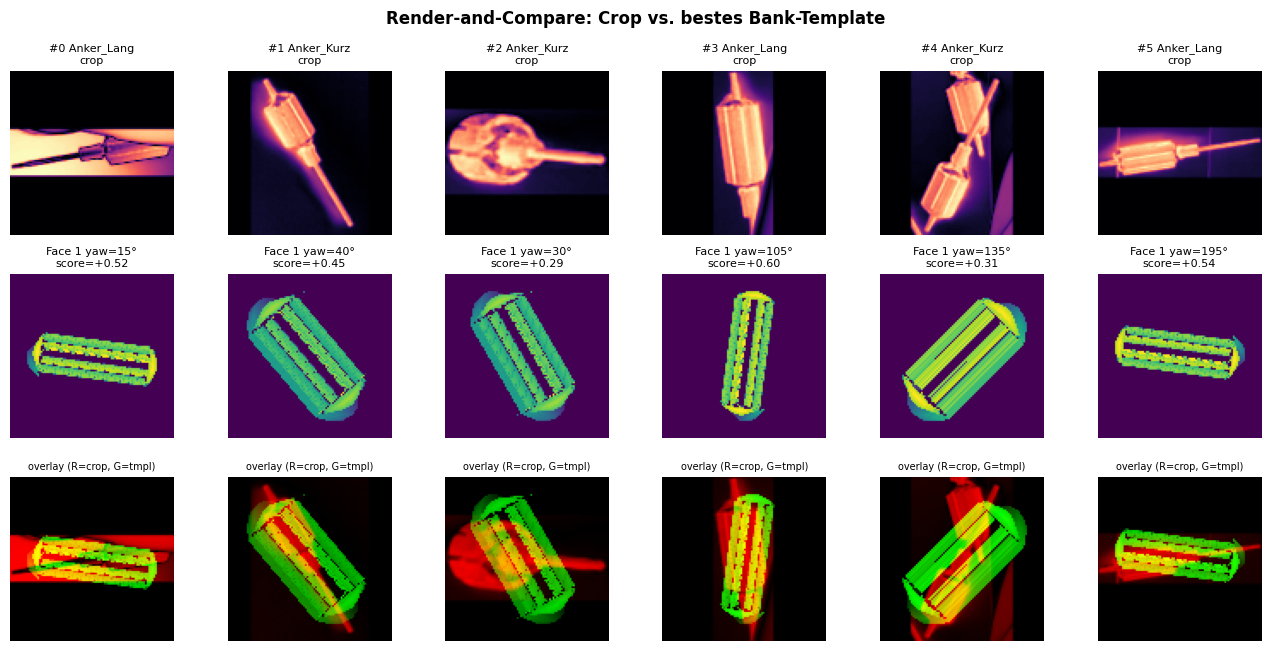

In [12]:
def show_template_match(aligned, k=6):
    """Crop-Relief | bestes Bank-Template | Überlagerung, pro Detection."""
    items = [a for a in aligned if a.get("pose_source") == "template_bank"][:k]
    if not items:
        print("keine Bank-Matches (keine Template-Bank?) — nichts zu zeigen"); return
    fig, axs = plt.subplots(3, len(items), figsize=(2.2*len(items), 6.6), squeeze=False)
    for j, it in enumerate(items):
        bank = load_template_bank(it["part"])
        q = _query_relief(it["crop"], bank["size"])
        tmpl = bank["depth"][it["template_idx"]]
        axs[0][j].imshow(q, cmap="magma"); axs[0][j].axis("off")
        axs[0][j].set_title(f"#{it['instance_id']} {it['part']}\ncrop", fontsize=8)
        axs[1][j].imshow(tmpl, cmap="viridis"); axs[1][j].axis("off")
        axs[1][j].set_title(f"{it['face_name']} yaw={it['yaw_deg']:.0f}°\nscore={it['match_score']:+.2f}", fontsize=8)
        ov = np.zeros((*q.shape, 3), np.float32); ov[..., 0] = q; ov[..., 1] = tmpl
        axs[2][j].imshow(np.clip(ov, 0, 1)); axs[2][j].axis("off")
        axs[2][j].set_title("overlay (R=crop, G=tmpl)", fontsize=7)
    fig.suptitle("Render-and-Compare: Crop vs. bestes Bank-Template", fontweight="bold")
    fig.tight_layout(); plt.show()

show_template_match(ALIGNED)

## 5 · pose_result — schema-valides JSON + 3D-Inline

Die Ergebnisse werden in das eingefrorene `pose_result`-Format gegossen und gegen
den Contract validiert (stdlib-Gate immer; jsonschema-Gate wenn verfügbar).


In [13]:
SCHEMA_VERSION = "1.0.0"
COORD_CONVENTION = ("Z-up world; column rotation world = R @ body (same as "
                    "faces_<part>.json registry); origin = table-plane null-point")

def _is_num(x): return isinstance(x, (int, float)) and not isinstance(x, bool)
def _is_int(x): return isinstance(x, int) and not isinstance(x, bool)

def check_pose_result(doc):
    """stdlib-Contract-Gate -> Liste von Verstößen (leer = gültig)."""
    e = []
    if not isinstance(doc, dict): return ["top level must be object"]
    meta = doc.get("meta", {})
    if not isinstance(meta.get("source_image"), str) or not meta.get("source_image"): e.append("meta.source_image")
    to = meta.get("table_origin")
    if not (isinstance(to, list) and len(to) == 3 and all(_is_num(v) for v in to)): e.append("meta.table_origin")
    if meta.get("units") != "m": e.append("meta.units must be 'm'")
    if not isinstance(meta.get("coordinate_convention"), str) or not meta.get("coordinate_convention"): e.append("meta.coordinate_convention")
    sv = meta.get("schema_version")
    if not (isinstance(sv, str) and sv.count(".") == 2 and all(p.isdigit() for p in sv.split("."))): e.append("meta.schema_version")
    res = doc.get("results")
    if not isinstance(res, list): return e + ["results must be array"]
    for i, r in enumerate(res):
        p = f"results[{i}]"
        if not (_is_int(r.get("instance_id")) and r["instance_id"] >= 0): e.append(f"{p}.instance_id")
        if not (isinstance(r.get("part"), str) and r["part"]): e.append(f"{p}.part")
        if not (isinstance(r.get("face"), str) and r["face"]): e.append(f"{p}.face")
        R = r.get("R_world")
        if not (isinstance(R, list) and len(R) == 9 and all(_is_num(v) for v in R)): e.append(f"{p}.R_world")
        t = r.get("t_world")
        if not (isinstance(t, list) and len(t) == 3 and all(_is_num(v) for v in t)): e.append(f"{p}.t_world")
        c = r.get("confidence")
        if not (_is_num(c) and 0.0 <= c <= 1.0): e.append(f"{p}.confidence")
        b = r.get("bbox_2d")
        if not (isinstance(b, list) and len(b) == 4 and all(_is_int(v) and v >= 0 for v in b)): e.append(f"{p}.bbox_2d")
        elif not (b[0] <= b[2] and b[1] <= b[3]): e.append(f"{p}.bbox_2d order")
        if not isinstance(r.get("upright"), bool): e.append(f"{p}.upright")
    return e

def build_pose_result(img_path, aligned, intr):
    return {
        "meta": {"source_image": str(img_path), "table_origin": [float(v) for v in intr.table_origin],
                 "units": "m", "coordinate_convention": COORD_CONVENTION, "schema_version": SCHEMA_VERSION},
        "results": [{"instance_id": int(a["instance_id"]), "part": a["part"], "face": a["face_name"],
                     "R_world": [float(v) for v in a["R_world"]], "t_world": [float(v) for v in a["t_world"]],
                     "confidence": float(max(0.0, min(1.0, a["confidence"]))),
                     "bbox_2d": [int(v) for v in a["bbox_2d"]], "upright": bool(a["upright"])}
                    for a in aligned],
    }

POSE = build_pose_result(IMG_PATH, ALIGNED, INTR)
errors = check_pose_result(POSE)
try:
    from jsonschema import Draft202012Validator
    # Contract liegt in project/ (committet); ältere docs/-Lage als Fallback.
    schema_file = next((p for p in (PROJECT / "pose_result.schema.json",
                                    PROJECT.parent / "docs" / "pose_result.schema.json")
                        if p.exists()), None)
    if schema_file:
        v = Draft202012Validator(json.load(open(schema_file)))
        errors += [f"[jsonschema] {'/'.join(str(x) for x in e.path)}: {e.message}" for e in v.iter_errors(POSE)]
except Exception:
    pass
assert not errors, f"pose_result NICHT contract-valid:\n  - " + "\n  - ".join(errors)
out = TEMP / "pose_result.json"; json.dump(POSE, open(out, "w"), indent=2)
print(f"[pose_result] {len(POSE['results'])} Teile, Schema-Gate PASS -> {out}")
print(json.dumps(POSE, indent=2)[:900])

[pose_result] 9 Teile, Schema-Gate PASS -> /Users/Admin/POSE/project/temp/pose_result.json
{
  "meta": {
    "source_image": "/Users/Admin/POSE/project/input/scene_0000.png",
    "table_origin": [
      0.0,
      0.0,
      0.08
    ],
    "units": "m",
    "coordinate_convention": "Z-up world; column rotation world = R @ body (same as faces_<part>.json registry); origin = table-plane null-point",
    "schema_version": "1.0.0"
  },
  "results": [
    {
      "instance_id": 0,
      "part": "Anker_Lang",
      "face": "Face 1",
      "R_world": [
        0.00030988515936769545,
        0.9913110733032227,
        0.13153581321239471,
        0.005558609031140804,
        -0.13153578341007233,
        0.991295576095581,
        0.9999849796295166,
        0.0004239999980200082,
        -0.005551000125706196
      ],
      "t_world": [
        0.31461454031738356,
        -0.026755175352621466,
        0.08
      ],
      "confidence": 0.7187700958135803,
      "bbox_2d": [
    


### Visualisierung — 3D-Inline (Teile an ihrer geschätzten Pose)

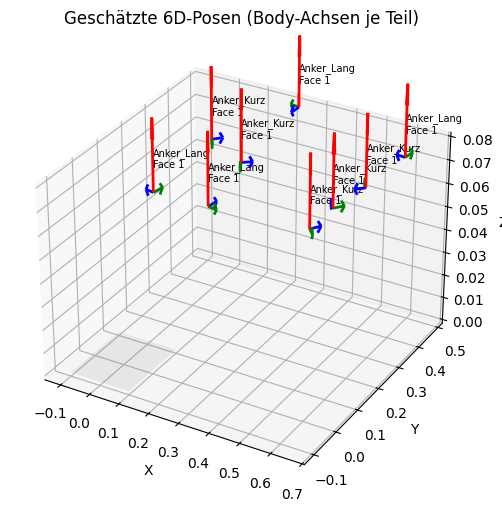

In [14]:
from mpl_toolkits.mplot3d import Axes3D  # noqa
def show_3d(pose):
    fig = plt.figure(figsize=(7, 6)); ax = fig.add_subplot(111, projection="3d")
    # Tischebene
    gx, gy = np.meshgrid(np.linspace(-0.1, 0.1, 2), np.linspace(-0.1, 0.1, 2))
    ax.plot_surface(gx, gy, np.zeros_like(gx), alpha=0.1, color="grey")
    for r in pose["results"]:
        t = np.array(r["t_world"]); R = np.array(r["R_world"]).reshape(3, 3)
        for axis, col in zip(range(3), ("r", "g", "b")):
            d = R[:, axis]*0.03
            ax.quiver(t[0], t[1], t[2], d[0], d[1], d[2], color=col, lw=2)
        ax.text(t[0], t[1], t[2]+0.01, f"{r['part']}\n{r['face']}", fontsize=7)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.set_title("Geschätzte 6D-Posen (Body-Achsen je Teil)"); plt.show()
show_3d(POSE)


## 6 · Live-3D-Viewer — localhost-Server + IFrame im Notebook

Das `pose_result.json` (in `temp/`) ist der **Contract** zwischen Pipeline und
3D-Viewer (`project/frontend/`). Der Viewer lädt das **echte Anlagen-CAD**
(`frontend/assets/cell.glb` — Tisch/Wagen + NEURA-LARA5-Arm + Trays) und legt die
rekonstruierten Teile per 6D-Pose relativ zum Tisch-Nullpunkt drauf. Die letzte
Zelle startet einen localhost-Server (ab `project/`, im Hintergrund) und bettet
den Viewer als IFrame direkt ins Notebook ein.

> **Stand (echt vs. dokumentiert):**
> - **Pose** kommt aus dem **Template-Bank-Match** (Render-and-Compare gegen das
>   echte CAD) — deterministisch, kein CNN-Raten.
> - **Backprojection metrisch** mit den echten Zivid-Intrinsics/Extrinsics aus
>   `GST_Scene.usd` — Teile landen an der richtigen Tray-Stelle.
> - **Detektor** (`models/detector.pt`) ist YOLOv8-OBB, auf den großen Multi-Part-
>   SDG-Szenen trainiert (5 Klassen). Fehlt die `.pt`/`ultralytics`, fällt Stufe 1
>   sauber auf die SDG-Annotator-Boxen bzw. eine Dummy-Box zurück.

In [15]:
# ── localhost-Server (Hintergrund, ab project/) + Viewer-IFrame im Notebook ──
import http.server, socketserver, threading, functools, contextlib
from IPython.display import IFrame, display

PORT = 8000
SERVE_ROOT = PROJECT                       # Server-Wurzel = project/  -> /frontend/ + /temp/
POSE_REL = (TEMP / "pose_result.json").relative_to(PROJECT).as_posix()   # temp/pose_result.json
VIEWER_URL = f"http://127.0.0.1:{PORT}/frontend/?file=../{POSE_REL}"

def _start_server(root, port):
    """Idempotenter Hintergrund-Server. No-op, wenn der Port schon belegt ist."""
    handler = functools.partial(http.server.SimpleHTTPRequestHandler, directory=str(root))
    try:
        socketserver.TCPServer.allow_reuse_address = True
        httpd = socketserver.TCPServer(("127.0.0.1", port), handler)
    except OSError:
        print(f"[serve] Port {port} schon belegt — nehme den laufenden Server an.")
        return None
    threading.Thread(target=httpd.serve_forever, daemon=True).start()
    print(f"[serve] http.server läuft (Hintergrund) ab {root} auf :{port}")
    return httpd

_HTTPD = _start_server(SERVE_ROOT, PORT)
print(f"[serve] Viewer-URL: {VIEWER_URL}")
print(f"[serve] {len(POSE['results'])} Teile im pose_result -> wird unten gerendert.")
# Three.js-Viewer direkt ins Notebook einbetten (zeigt Tisch + Teile an 6D-Pose):
display(IFrame(src=VIEWER_URL, width="100%", height=560))


[serve] http.server läuft (Hintergrund) ab /Users/Admin/POSE/project auf :8000
[serve] Viewer-URL: http://127.0.0.1:8000/frontend/?file=../temp/pose_result.json
[serve] 9 Teile im pose_result -> wird unten gerendert.
